# STURM-Flood Dataset Inspection

This notebook inspects the STURM-Flood dataset as the second dataset in the disaster benchmarking framework.

The goal is to understand its folder structure, Sentinel-1 and Sentinel-2 files, floodmap masks, metadata CSV files, raster properties, and image-mask pairing.


## Why this dataset matters

Unlike xBD/xView2, which uses building polygons and damage labels, STURM-Flood uses raster GeoTIFF images and floodmap masks. This makes it useful for testing whether the framework can support mask-based semantic segmentation datasets.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt


In [2]:
CONFIG_PATH = Path('../configs/sturm_flood_config.json')

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

DATASET_ROOT = Path('..') / config['dataset_path']

DATASET_ROOT


PosixPath('../datasets/sturm_flood_raw')

## Dataset paths

The dataset contains Sentinel-1 images, Sentinel-1 floodmaps, Sentinel-2 images, Sentinel-2 floodmaps, and metadata CSV files.


In [3]:
paths = {
    'sentinel1_images': DATASET_ROOT / config['sentinel1']['image_folder'],
    'sentinel1_floodmaps': DATASET_ROOT / config['sentinel1']['floodmap_folder'],
    'sentinel1_metadata': DATASET_ROOT / config['sentinel1']['metadata_file'],
    'sentinel2_images': DATASET_ROOT / config['sentinel2']['image_folder'],
    'sentinel2_floodmaps': DATASET_ROOT / config['sentinel2']['floodmap_folder'],
    'sentinel2_metadata': DATASET_ROOT / config['sentinel2']['metadata_file'],
}

for name, path in paths.items():
    print(name, '->', path)
    print('exists:', path.exists())


sentinel1_images -> ../datasets/sturm_flood_raw/Sentinel1/S1
exists: True
sentinel1_floodmaps -> ../datasets/sturm_flood_raw/Sentinel1/Floodmaps
exists: True
sentinel1_metadata -> ../datasets/sturm_flood_raw/sentinel1_metadata.csv
exists: True
sentinel2_images -> ../datasets/sturm_flood_raw/Sentinel2/S2
exists: True
sentinel2_floodmaps -> ../datasets/sturm_flood_raw/Sentinel2/Floodmaps
exists: True
sentinel2_metadata -> ../datasets/sturm_flood_raw/sentinel2_metadata.csv
exists: True


## File counts

This checks the number of image and floodmap files for Sentinel-1 and Sentinel-2.


In [4]:
s1_images = sorted(paths['sentinel1_images'].glob('*.tif'))
s1_floodmaps = sorted(paths['sentinel1_floodmaps'].glob('*.tif'))
s2_images = sorted(paths['sentinel2_images'].glob('*.tif'))
s2_floodmaps = sorted(paths['sentinel2_floodmaps'].glob('*.tif'))

print('Sentinel-1 images:', len(s1_images))
print('Sentinel-1 floodmaps:', len(s1_floodmaps))
print('Sentinel-2 images:', len(s2_images))
print('Sentinel-2 floodmaps:', len(s2_floodmaps))


Sentinel-1 images: 21602
Sentinel-1 floodmaps: 21602
Sentinel-2 images: 2675
Sentinel-2 floodmaps: 2675


## Metadata inspection

The metadata files describe each tile using fields such as EMS code, AOI code, country, event type, tile ID, EPSG code, and acquisition dates.


In [5]:
s1_meta = pd.read_csv(paths['sentinel1_metadata'])
s2_meta = pd.read_csv(paths['sentinel2_metadata'])

print('Sentinel-1 metadata shape:', s1_meta.shape)
print('Sentinel-2 metadata shape:', s2_meta.shape)

display(s1_meta.head())
display(s2_meta.head())


Sentinel-1 metadata shape: (21602, 10)
Sentinel-2 metadata shape: (2675, 10)


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,epsg_code,floodmap_date,sentinel_date
0,0,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_1_2_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
1,1,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_2_2_1.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
2,2,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_2_2_2_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
3,3,EMSR260,02VIADANA,EMSR260_02VIADANA_DEL_MONIT01_v2,Riverine flood,Italy,EMSR260_02VIADANA_3_2_1_2.tif,32632,2017-12-14 05:10:00,2017-12-12 05:27:24
4,4,EMSR260,09RUBIERA,EMSR260_09RUBIERA_DEL_MONIT01_v1,Riverine flood,Italy,EMSR260_09RUBIERA_1_1_2_2.tif,32632,2017-12-13 05:18:00,2017-12-12 05:27:24


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,epsg_code,floodmap_date,sentinel_timestamp
0,0,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_1_1.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
1,1,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_2_1.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
2,2,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_17_16_2_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
3,3,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_19_18_1_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51
4,4,EMSR279,03ALFARO,EMSR279_03ALFARO_DEL_v1,Riverine flood,Spain,EMSR279_03ALFARO_19_18_2_2.tif,32630,2018-04-14 20:03:00,2018-04-14 10:56:51


## Image-mask-metadata pairing check

This verifies that every satellite image has a matching floodmap and metadata row using the filename / tile_id.


In [6]:
def pairing_check(image_files, mask_files, metadata, dataset_name):
    image_names = {p.name for p in image_files}
    mask_names = {p.name for p in mask_files}
    metadata_ids = set(metadata['tile_id'].astype(str))

    result = {
        'dataset': dataset_name,
        'image_files': len(image_names),
        'floodmap_files': len(mask_names),
        'metadata_rows': len(metadata),
        'images_without_floodmaps': len(image_names - mask_names),
        'floodmaps_without_images': len(mask_names - image_names),
        'images_missing_from_metadata': len(image_names - metadata_ids),
        'metadata_rows_missing_image_file': len(metadata_ids - image_names),
    }
    return result

pairing_results = [
    pairing_check(s1_images, s1_floodmaps, s1_meta, 'sentinel1'),
    pairing_check(s2_images, s2_floodmaps, s2_meta, 'sentinel2'),
]

pd.DataFrame(pairing_results)


,dataset,image_files,floodmap_files,metadata_rows,images_without_floodmaps,floodmaps_without_images,images_missing_from_metadata,metadata_rows_missing_image_file
0,sentinel1,21602,21602,21602,0,0,0,0
1,sentinel2,2675,2675,2675,0,0,0,0


## Raster inspection

This checks technical raster properties such as width, height, band count, data type, CRS, bounds, and value range.


In [7]:
def inspect_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        return {
            'file': path.name,
            'width': src.width,
            'height': src.height,
            'bands': src.count,
            'dtypes': src.dtypes,
            'crs': str(src.crs),
            'bounds': src.bounds,
            'min_band1': float(np.nanmin(arr)),
            'max_band1': float(np.nanmax(arr)),
            'unique_values_sample': np.unique(arr)[:20].tolist(),
        }

raster_results = [
    inspect_raster(s1_images[0]),
    inspect_raster(s1_floodmaps[0]),
    inspect_raster(s2_images[0]),
    inspect_raster(s2_floodmaps[0]),
]

pd.DataFrame(raster_results)


,file,width,height,bands,dtypes,crs,bounds,min_band1,max_band1,unique_values_sample
0,EMSR260_02VIADANA_2_1_2_2.tif,128,128,2,"(float32, float32)",EPSG:32632,"(620220.0, 4973850.0, 621500.0, 4975130.0)",0.112307,0.835591,"[0.1123068779706955, 0.11773648113012314, 0.11..."
1,EMSR260_02VIADANA_2_1_2_2.tif,128,128,1,"(uint8,)",EPSG:32632,"(620220.0, 4973850.0, 621500.0, 4975130.0)",0.000000,5.000000,"[0, 2, 5]"
2,EMSR279_03ALFARO_17_16_1_1.tif,128,128,9,"(float64, float64, float64, float64, float64, ...",EPSG:32630,"(596421.000714, 4676670.6029, 597701.000714, 4...",-0.270833,1.015000,"[-0.2708333333333333, -0.2575, -0.255833333333..."
3,EMSR279_03ALFARO_17_16_1_1.tif,128,128,1,"(int32,)",EPSG:32630,"(596421.000714, 4676670.6029, 597701.000714, 4...",0.000000,2.000000,"[0, 1, 2]"


## Mask value inspection

The floodmaps are raster masks. Each pixel value represents a class. The original STURM-Flood mask values include flooded area, river-related features, open water, reservoirs, lakes, and no-data.


In [8]:
mask_legend = config['annotation']['original_mask_values']
mask_legend


{'0': 'coastline_or_area_of_interest',
 '1': 'flooded_area',
 '2': 'river_related_features',
 '3': 'open_water',
 '4': 'reservoirs',
 '5': 'lakes',
 '99': 'no_data'}

In [9]:
def get_unique_mask_values(mask_files, max_files=100):
    values = set()
    for path in mask_files[:max_files]:
        with rasterio.open(path) as src:
            arr = src.read(1)
            values.update(np.unique(arr).tolist())
    return sorted(values)

print('Sentinel-1 mask values from first 100 files:', get_unique_mask_values(s1_floodmaps, 100))
print('Sentinel-2 mask values from first 100 files:', get_unique_mask_values(s2_floodmaps, 100))


Sentinel-1 mask values from first 100 files: [0, 1, 2, 4, 5]
Sentinel-2 mask values from first 100 files: [0, 1, 2, 3, 4, 5]


## Visualization

This displays one satellite image and its matching floodmap. For Sentinel-1, band 1 is shown. For Sentinel-2, an RGB composite is created using B4, B3, and B2 if available in the configured band order.


In [16]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

OUTPUT_DIR = Path("../outputs/sturm_flood_inspection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASK_CLASSES = {
    0: "coastline / area of interest",
    1: "flooded area",
    2: "river-related features",
    3: "open water",
    4: "reservoirs",
    5: "lakes",
    99: "no data"
}

MASK_COLORS = {
    0: "#d9d9d9",
    1: "#ff0000",
    2: "#0066ff",
    3: "#00ffff",
    4: "#ff9900",
    5: "#00cc44",
    99: "#000000"
}

mask_values_order = [0, 1, 2, 3, 4, 5, 99]
mask_cmap = ListedColormap([MASK_COLORS[v] for v in mask_values_order])
mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 99.5], mask_cmap.N)

legend_handles = [
    Patch(facecolor=MASK_COLORS[value], edgecolor="black", label=f"{value}: {label}")
    for value, label in MASK_CLASSES.items()
]

Saved: ../outputs/sturm_flood_inspection/sentinel1_sample_0_inspection.png


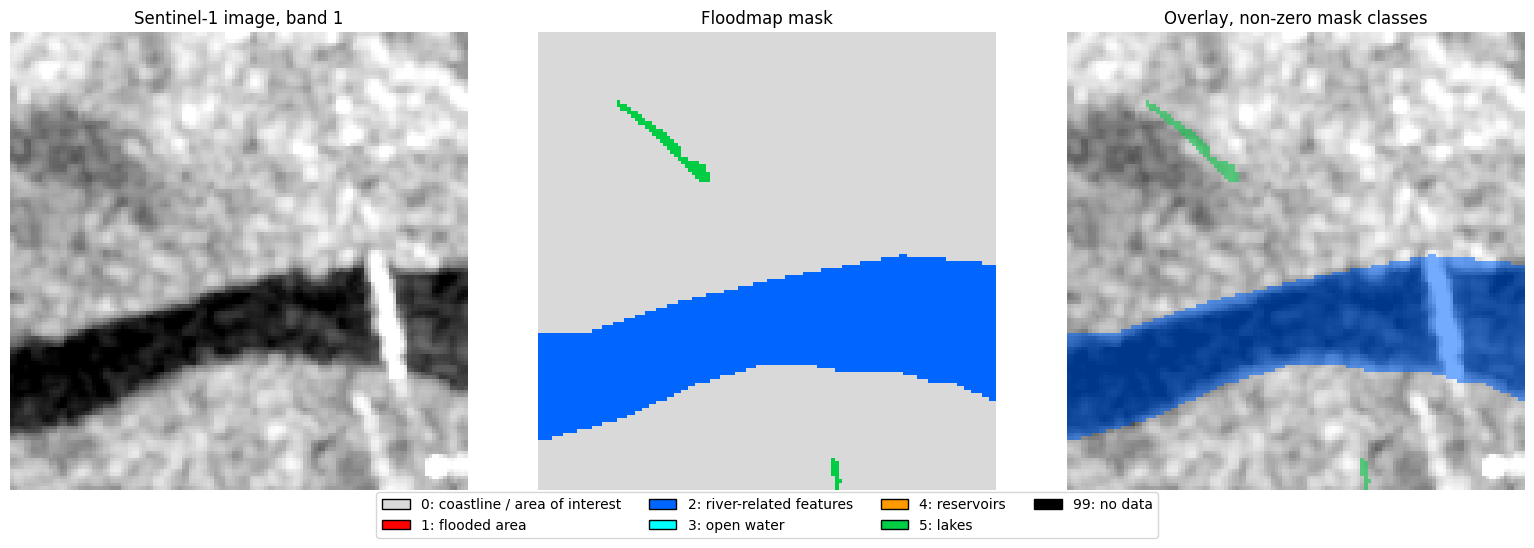

In [17]:
def normalize_for_display(arr):
    arr = arr.astype(float)
    p2, p98 = np.nanpercentile(arr, (2, 98))
    if p98 - p2 == 0:
        return np.zeros_like(arr)
    arr = (arr - p2) / (p98 - p2)
    return np.clip(arr, 0, 1)

def show_sentinel1_sample(index=0, save=True):
    image_path = s1_images[index]
    mask_path = paths["sentinel1_floodmaps"] / image_path.name

    with rasterio.open(image_path) as src:
        image = src.read(1)

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(normalize_for_display(image), cmap="gray")
    axes[0].set_title("Sentinel-1 image, band 1")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap=mask_cmap, norm=mask_norm)
    axes[1].set_title("Floodmap mask")
    axes[1].axis("off")

    axes[2].imshow(normalize_for_display(image), cmap="gray")
    overlay_mask = np.ma.masked_where(mask == 0, mask)
    axes[2].imshow(overlay_mask, cmap=mask_cmap, norm=mask_norm, alpha=0.55)
    axes[2].set_title("Overlay, non-zero mask classes")
    axes[2].axis("off")

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()

    if save:
        output_path = OUTPUT_DIR / f"sentinel1_sample_{index}_inspection.png"
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print("Saved:", output_path)

    plt.show()

show_sentinel1_sample(0)


Saved: ../outputs/sturm_flood_inspection/sentinel2_sample_0_inspection.png


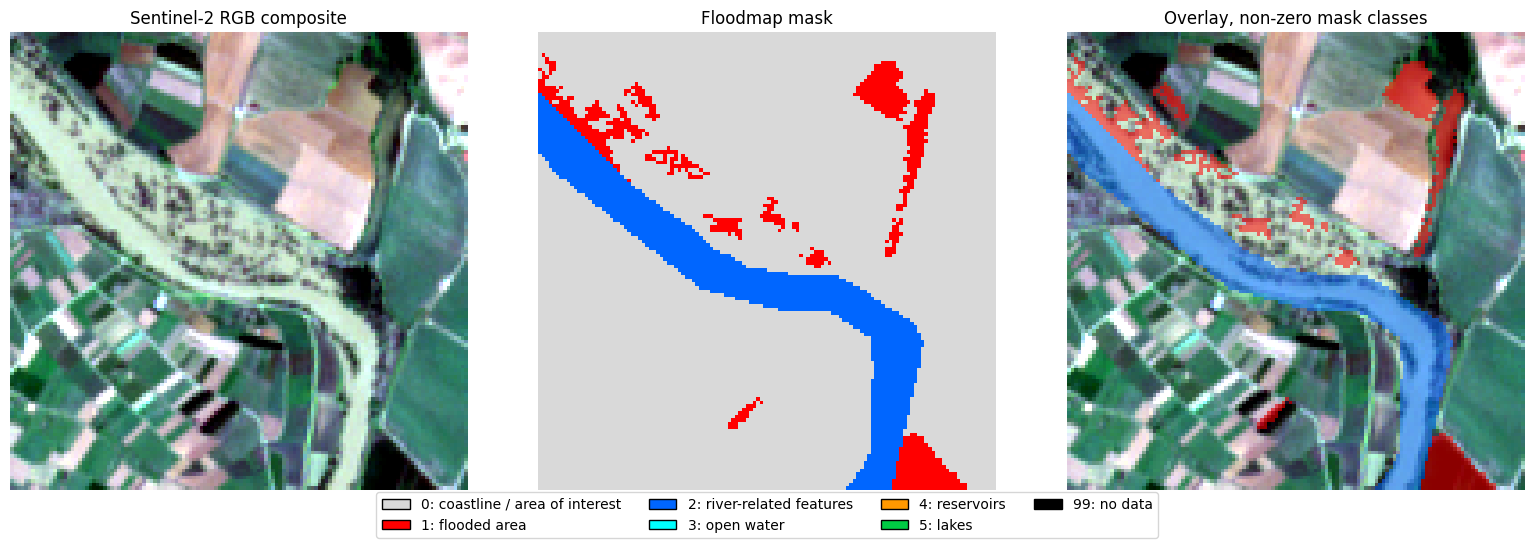

In [18]:
def show_sentinel2_sample(index=0, save=True):
    image_path = s2_images[index]
    mask_path = paths["sentinel2_floodmaps"] / image_path.name

    with rasterio.open(image_path) as src:
        blue = src.read(1)
        green = src.read(2)
        red = src.read(3)

        rgb = np.dstack([
            normalize_for_display(red),
            normalize_for_display(green),
            normalize_for_display(blue)
        ])

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(rgb)
    axes[0].set_title("Sentinel-2 RGB composite")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap=mask_cmap, norm=mask_norm)
    axes[1].set_title("Floodmap mask")
    axes[1].axis("off")

    axes[2].imshow(rgb)
    overlay_mask = np.ma.masked_where(mask == 0, mask)
    axes[2].imshow(overlay_mask, cmap=mask_cmap, norm=mask_norm, alpha=0.55)
    axes[2].set_title("Overlay, non-zero mask classes")
    axes[2].axis("off")

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()

    if save:
        output_path = OUTPUT_DIR / f"sentinel2_sample_{index}_inspection.png"
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print("Saved:", output_path)

    plt.show()

show_sentinel2_sample(0)

In [19]:
inspection_summary = {
    "dataset_id": config["dataset_id"],
    "dataset_name": config["dataset_name"],
    "task_type": config["task_type"],
    "problem_type": config["problem_type"],
    "data_format": config["data_format"],
    "tile_size": config["tile_size"],
    "spatial_resolution_m": config["spatial_resolution_m"],

    "sentinel1": {
        "image_count": len(s1_images),
        "floodmap_count": len(s1_floodmaps),
        "metadata_rows": len(s1_meta),
        "bands": config["sentinel1"]["image_bands"],
        "expected_band_count": config["sentinel1"]["expected_band_count"]
    },

    "sentinel2": {
        "image_count": len(s2_images),
        "floodmap_count": len(s2_floodmaps),
        "metadata_rows": len(s2_meta),
        "bands": config["sentinel2"]["image_bands"],
        "expected_band_count": config["sentinel2"]["expected_band_count"]
    },

    "pairing_check": pairing_results,
    "mask_classes": MASK_CLASSES,
    "binary_water_mapping": config["annotation"]["binary_water_mapping"],

    "framework_relevance": (
        "STURM-Flood is used as the second dataset to test raster-mask semantic "
        "segmentation support in the common disaster remote sensing benchmarking framework."
    )
}

summary_path = OUTPUT_DIR / "sturm_flood_inspection_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(inspection_summary, f, indent=2)

print("Saved:", summary_path)

Saved: ../outputs/sturm_flood_inspection/sturm_flood_inspection_summary.json


## Initial observations

- STURM-Flood is a raster-mask based semantic segmentation dataset.
- Sentinel-1 has 21,602 image-mask pairs and Sentinel-2 has 2,675 image-mask pairs.
- Each image has a matching floodmap and metadata row.
- Sentinel-1 samples contain 2 bands, while Sentinel-2 samples contain 9 bands.
- Floodmaps are single-band masks with integer class values.
- This dataset is structurally different from xBD/xView2, making it useful for testing the common dataloader and schema framework.
